# Chapter 17 — Linear-in-$n$: Nyström and landmarks

*Companion notebook to **The Learned Kernel**, Ch. 17. Run top to bottom.*

Matrix-free (Ch. 16) removed the memory wall exactly, but the flop wall — $O(n^2)$ — still stands.
To go **linear in $n$**, approximate the kernel by its own Nyström feature map on $m$ landmark points
and solve a primal ridge in that map at $O(n m^2 + m^3)$. Both walls fall at once, at the price of an
approximation floor set by the discarded spectral tail. This notebook shows the linear scaling with
flat memory, the graceful degradation as landmarks shrink, and the random-Fourier cousin.

## Setup (GPU strongly recommended)

In [1]:
try:
    import lkbook  # noqa: F401
except ModuleNotFoundError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
        "learned-kernel[notebooks] @ git+https://github.com/asudjianto-xml/Learned-Kernel.git"],
        check=True)

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")

from lkbook import set_style
from lkbook.chapters import ch15, ch17

set_style()

## 17.1  The Nyström map and the primal solve

From the landmark Gram $K_{mm}=V\Lambda V^\top$, the projector $P=V_r\Lambda_r^{-1/2}$ gives the map
$\tilde\phi(x)=k(x,S)P$, whose Euclidean inner products reproduce the low-rank kernel
$K\approx\tilde\Phi\tilde\Phi^\top$. The dual $n\times n$ solve becomes a primal $r\times r$ ridge,
streamed over the train set — the $n\times n$ Gram never exists.

In [3]:
r = ch17.nystrom_vs_exact(n=6000, m=400)
print(f"exact decode   : R2 = {r['r2_exact']:.3f}   peak {r['exact_peak_gb']:.2f} GB")
print(f"Nystrom (m=400): R2 = {r['r2_nystrom']:.3f}   peak {r['nystrom_peak_gb']:.2f} GB")

exact decode   : R2 = 0.760   peak 1.45 GB
Nystrom (m=400): R2 = 0.729   peak 0.37 GB


## 17.2  Linear in $n$, flat memory

With the landmarks fixed, fit time rises linearly with $n$ while peak memory stays flat: the
$n\times n$ Gram is never formed. The dense path of Ch. 15 had already run out of memory by
$n=50{,}000$.

In [4]:
sc = ch17.scaling_curve((8000, 16000, 32000, 64000), m=512)
print(f"{'n':>8} {'fit_s':>8} {'peak_GB':>9} {'test_R2':>9}")
for row in sc:
    print(f"{row['n']:>8} {row['fit_s']:>8.3f} {row['peak_gb']:>9.2f} {row['r2']:>9.3f}")

       n    fit_s   peak_GB   test_R2
    8000    0.028      0.18     0.740
   16000    0.060      0.21     0.744
   32000    0.113      0.22     0.745
   64000    0.219      0.22     0.745


The measured GB10 reference on the learned kernel holds peak memory between 2 and 17.5 GB while $n$
grows from 20,000 to 1,000,000 (a 50× increase), with $R^2$ steady near 0.906.

## 17.3  Choosing $m$: graceful degradation

The landmark count is set by the spectral decay — the Nyström error scales with the discarded tail
$\sum_{i>m}\lambda_i(K)$. Accuracy degrades gracefully as the landmark fraction shrinks; the
practical knee is near 12%.

In [5]:
lc = ch17.landmark_curve(n=6000)
print(f"exact decode R2 = {lc['r2_exact']:.3f}")
print(f"{'frac':>6} {'m':>6} {'test_R2':>9} {'fit_s':>8}")
for row in lc["rows"]:
    print(f"{row['frac']*100:>5.0f}% {row['m']:>6} {row['r2']:>9.3f} {row['fit_s']:>8.3f}")

exact decode R2 = 0.760
  frac      m   test_R2    fit_s
    1%     60     0.625    0.003
    2%    120     0.686    0.006
    4%    240     0.714    0.012
    8%    480     0.730    0.033
   12%    720     0.736    0.066
   20%   1200     0.749    0.164
   40%   2400     0.754    0.719


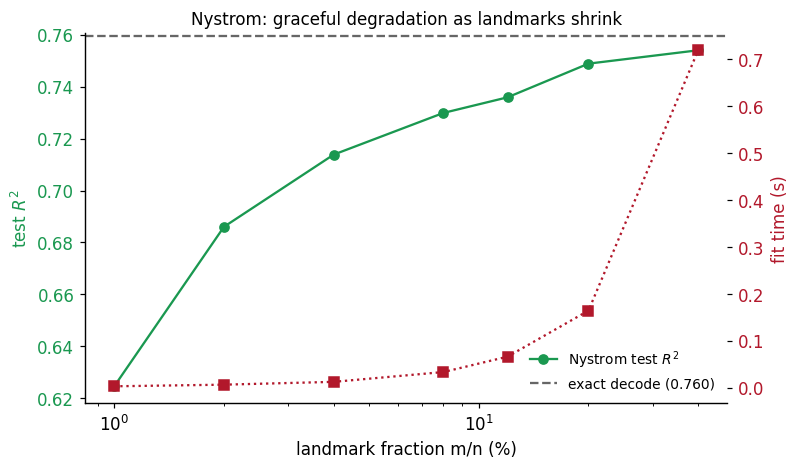

In [6]:
ch17.make_landmark_figure(lc);

### Interactive: dial the landmark budget

Slide the landmark fraction $m/n$ and watch accuracy approach the exact decode, degrading gracefully
below the ~12% knee. The landmark budget is a compute–accuracy dial set by the spectral decay.

In [7]:
try:
    from ipywidgets import interact, FloatSlider
    curve = {row["frac"]: row for row in lc["rows"]}

    def show(frac=0.12):
        k = min(curve, key=lambda x: abs(x - frac))
        row = curve[k]
        gap = lc["r2_exact"] - row["r2"]
        print(f"landmark fraction ~ {k*100:.0f}%   (m = {row['m']})")
        print(f"  Nystrom test R2 = {row['r2']:.3f}   (exact {lc['r2_exact']:.3f}, gap {gap:.3f})")
        print(f"  fit time = {row['fit_s']:.3f} s")

    interact(show, frac=FloatSlider(min=0.01, max=0.4, step=0.01, value=0.12,
                                    description="m/n"))
except Exception as e:
    print("widget unavailable:", e)

interactive(children=(FloatSlider(value=0.12, description='m/n', max=0.4, min=0.01, step=0.01), Output()), _do…

## 17.4  Cousins: random Fourier features

Random Fourier features sample $M$ frequencies from the spectral measure, giving an **explicit**
finite map and an **exact** primal ridge — no landmarks, a resolution cost in $M$. Accuracy rises
monotonically with the frequency budget.

In [8]:
Xtr, ytr, Xte, yte, ym, ys = ch15.load_california_scaled()
for M in (256, 512, 1024):
    p = ch17.rff_solve(Xtr, ytr, Xte, M=M, ell=2.0)
    print(f"RFF  M={M:>5}  test R2 = {ch15.r2_score(p, yte, ym, ys):.3f}")

RFF  M=  256  test R2 = 0.745
RFF  M=  512  test R2 = 0.756


RFF  M= 1024  test R2 = 0.758


## 17.5  The auto ladder

One trained kernel, three decoders. `solver="auto"` runs dense up to `n_dense`, then matrix-free,
then Nyström — each handing off where the previous wall arrives. The choice is a compute decision,
not a modeling one.

In [9]:
for n in (1_000, 30_000, 200_000, 5_000_000):
    print(f"n={n:>9,}  ->  solver = {ch17.auto_ladder(n)}")

n=    1,000  ->  solver = dense
n=   30,000  ->  solver = dense
n=  200,000  ->  solver = matfree
n=5,000,000  ->  solver = nystrom


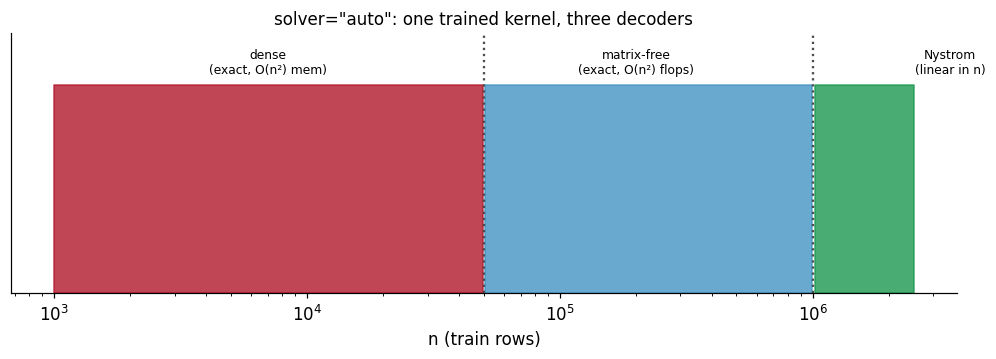

In [10]:
ch17.make_ladder_figure();

## Exercises

**(easy)** Show $\tilde\phi(x)=\Lambda_r^{-1/2}V_r^\top k(x,S)$ has Euclidean inner products that
reproduce the Nyström approximation $k(x,S)K_{mm}^{-1}k(S,x')$.

<details><summary>Solution</summary>

$\langle\tilde\phi(x),\tilde\phi(x')\rangle=k(x,S)PP^\top k(S,x')$ and
$PP^\top=V_r\Lambda_r^{-1}V_r^\top=K_{mm}^{-1}$ at full landmark rank, giving the Nyström form.
§17.1's test confirms the reproduction numerically.
</details>

**(medium)** Given a sharp eigenvalue knee at index $r_0$, argue $m$ slightly above $r_0$ suffices,
and relate the residual to $\sum_{i>m}\lambda_i(K)$.

<details><summary>Solution</summary>

The Nyström residual in trace norm is bounded by the discarded tail $\sum_{i>m}\lambda_i(K)$. A sharp
knee means the tail past $r_0$ is tiny, so $m$ just above $r_0$ captures nearly all of $K$; adding
landmarks past the knee buys almost nothing — the graceful-degradation curve in §17.3 flattens above
the ~12% knee.
</details>

**(⋆)** State the Nyström error bound in terms of $\sum_{i>m}\lambda_i(K)$ and contrast uniform and
leverage-score sampling.

<details><summary>Solution</summary>

Expected error $\lesssim \sum_{i>m}\lambda_i(K)$ up to a sampling factor. Leverage-score sampling is
variance-optimal (weights points by their influence on the top eigenspace); uniform sampling replaces
the leverage weights by uniform ones and picks up the coherence factor, which is $O(1)$ when the
spectrum decays fast — so uniform suffices under fast decay, leverage-score for heavy tails.
</details>